# Mosaic integration: [RNA, RNA + ATAC, ATAC], every method

This notebook runs every method that has a variant for mosaic [RNA, RNA + ATAC, ATAC] on `D45mini`: Cobolt, MultiVI, Multigrate, SMILE, StabMap and scMoMaT. The [tutorial](https://dsichang.github.io/scMultiBench/tutorials/mosaic_rna_atac/) explains each step and runs StabMap and scMoMaT only.

Methods run on Linux. The environments are 6 envs, 15.6 GB to download on a CPU host, 20.8 GB on a GPU host.

## 1. Install

This cell installs `multibench-sc`. It keeps the numpy and pandas that are already installed, so Colab needs no restart.

<details>
<summary>Details</summary>

On Colab, choose a GPU runtime before you run the notebook: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, an environment that has a smaller CPU build gets that build, and training methods run slower.

</details>

In [1]:
import numpy, pandas
%pip install -q multibench-sc numpy=={numpy.__version__} pandas=={pandas.__version__}

Note: you may need to restart the kernel to use updated packages.


## 2. Download the data and the environments

In [2]:
import pandas as pd
import multibench as mtb

mtb.data.fetch("D45mini")

PosixPath('/tmp/mbverify/home/.cache/multibench/data')

In [3]:
METHODS = ["Cobolt", "MultiVI", "Multigrate", "SMILE", "StabMap", "scMoMaT"]
envs = mtb.env.install(METHODS, dry_run=False)
pd.DataFrame(envs)[["env", "methods", "state"]]

,env,methods,state
0,env_sciPENN,[SMILE],have
1,scmb_cobolt3,[Cobolt],have
2,scmb_multigrate2,[Multigrate],have
3,scmb_multivi,[MultiVI],have
4,scmb_r,[StabMap],have
5,scmb_torch,[scMoMaT],have


## 3. Run the methods

In [4]:
res = mtb.run_all("D45mini", "mosaic", methods=METHODS,
                  out_dir="out/D45mini_all")
res.summary

[run_all] 9 more rows need files this folder does not have. mtb.scan shows them.


[run_all] Cobolt (mosaic/D45mini) ...


[run_all]   -> CHAIN_OK (119.1s) ARI 0.673


[run_all] MultiVI (mosaic/D45mini) ...


[run_all]   -> CHAIN_OK (292.4s) ARI 0.425


...

[run_all] StabMap (mosaic/D45mini) ...


[run_all]   -> CHAIN_OK (13.9s) ARI 0.618


[run_all] scMoMaT (mosaic/D45mini) ...


[run_all]   -> CHAIN_OK_GRAPH_METHOD (91.8s) ARI 0.289


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,...,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,Cobolt,CHAIN_OK,119.1,embedding,"[6000, 10]",2,cty1.csv+cty2.csv+cty3.csv,0.0,file_of_origin,3,...,0.5659,0.5976,0.7400,0.9828,0.9241,0.9771,0.8200,None,,
1,MultiVI,CHAIN_OK,292.4,embedding,"[6000, 8]",0,cty1.csv+cty2.csv+cty3.csv,0.0,file_of_origin,3,...,0.5671,0.6203,0.7120,0.9940,0.9544,0.9305,0.8677,None,,
2,Multigrate,CHAIN_OK,105.9,embedding,"[6000, 15]",2,cty1.csv+cty2.csv+cty3.csv,0.0,file_of_origin,3,...,0.5038,0.4992,0.4984,0.9120,0.9111,0.8884,0.4594,None,"Multigrate needs about 1,300 cells in every ba...",
3,SMILE,CHAIN_OK,48.1,embedding,"[6000, 20]",0,cty1.csv+cty2.csv+cty3.csv,0.0,file_of_origin,3,...,0.4788,0.4976,0.4792,0.9325,0.9369,0.8795,0.7769,None,,
4,StabMap,CHAIN_OK,13.9,embedding,"[6000, 50]",0,cty1.csv+cty2.csv+cty3.csv,0.0,file_of_origin,3,...,0.5177,0.5393,0.7312,0.9510,0.8541,0.9783,0.4320,None,,
5,scMoMaT,CHAIN_OK_GRAPH_METHOD,91.8,graph,"[6000, 2]",0,cty1.csv+cty2.csv+cty3.csv,0.0,file_of_origin,3,...,0.4992,0.4962,0.5417,0.9614,0.6807,0.6867,0.6510,None,,


## 4. Plot

`res.plot()` draws the scores as a bubble table. Circle size shows the rank within a column, and bigger is better. The fill compares a value with the other rows in the same column.

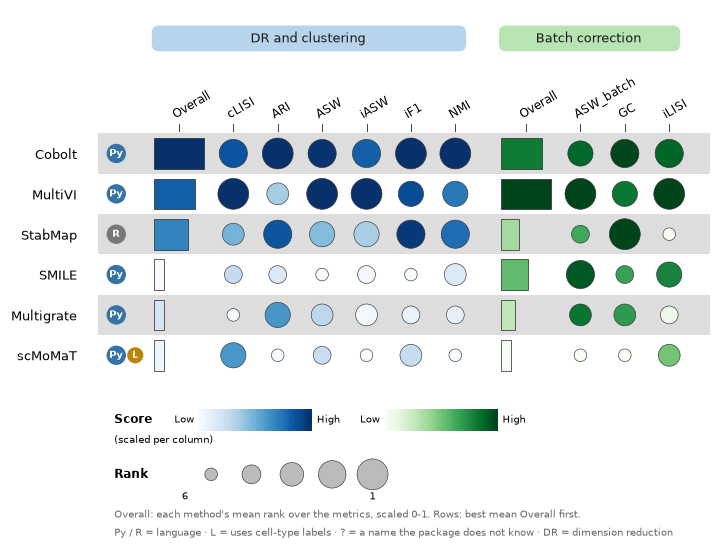

In [5]:
res.plot()